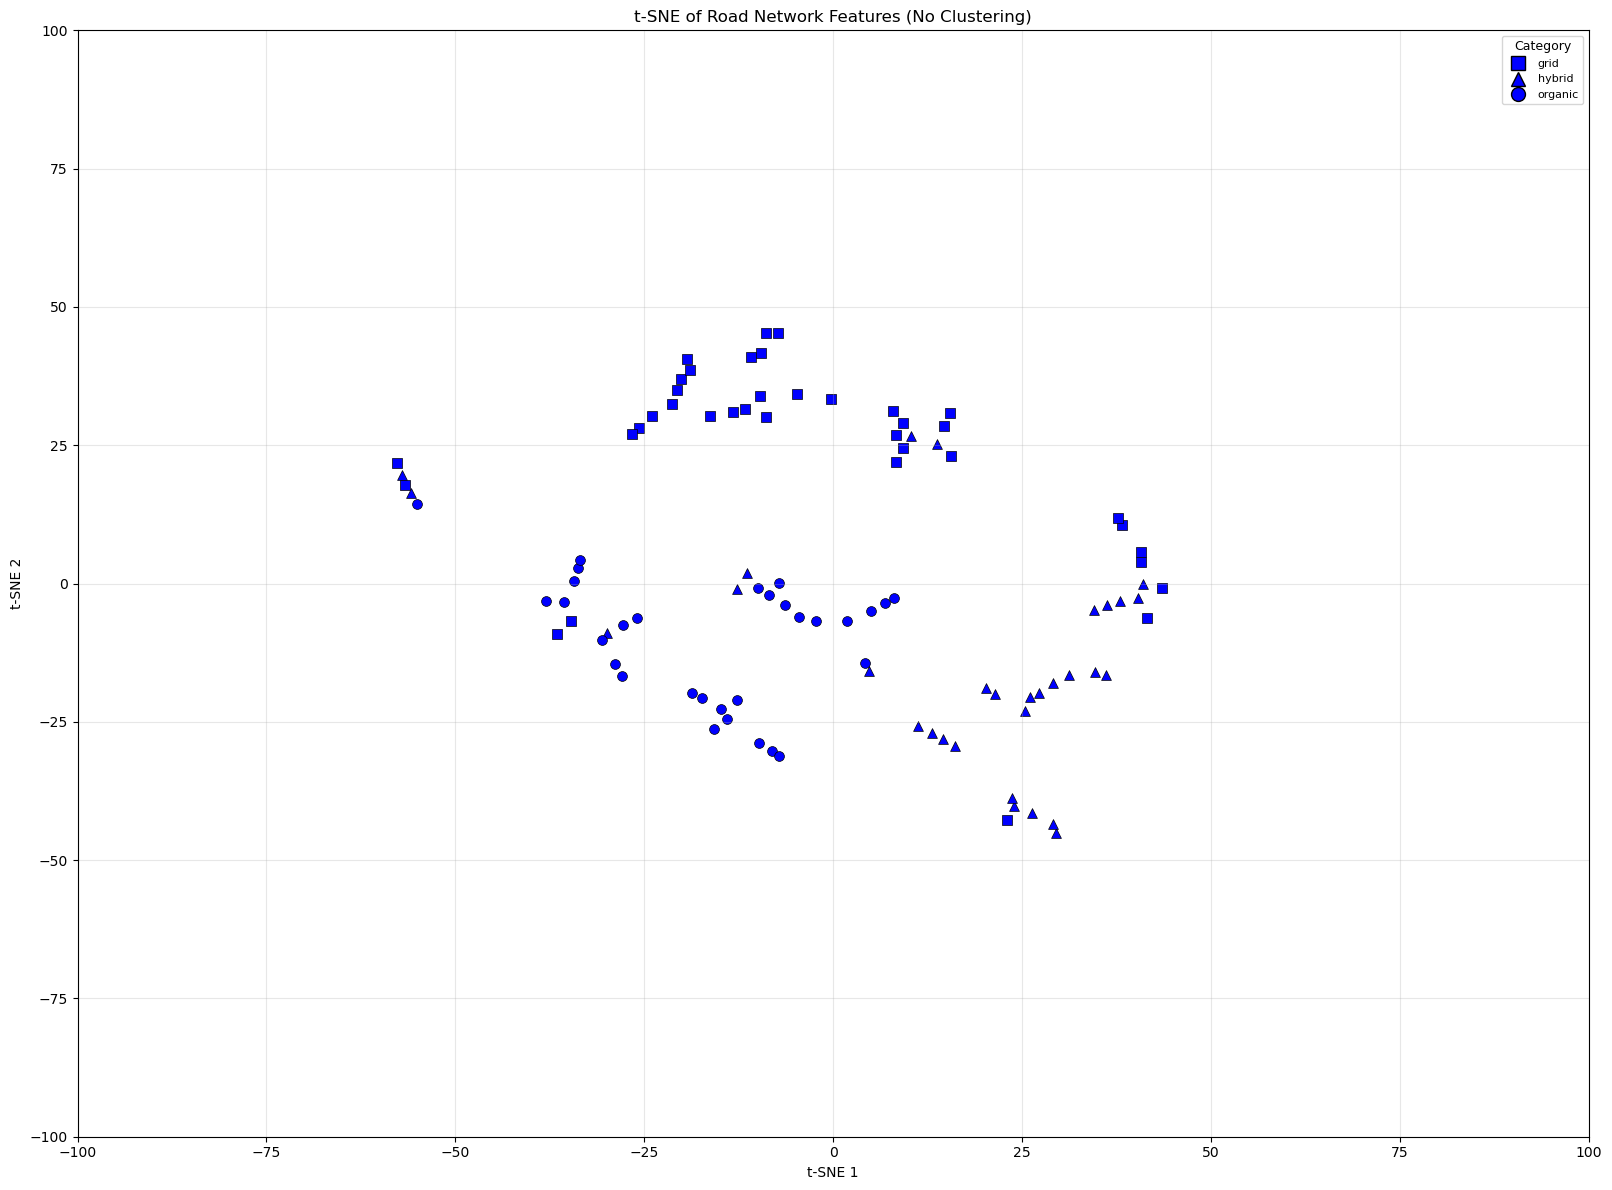

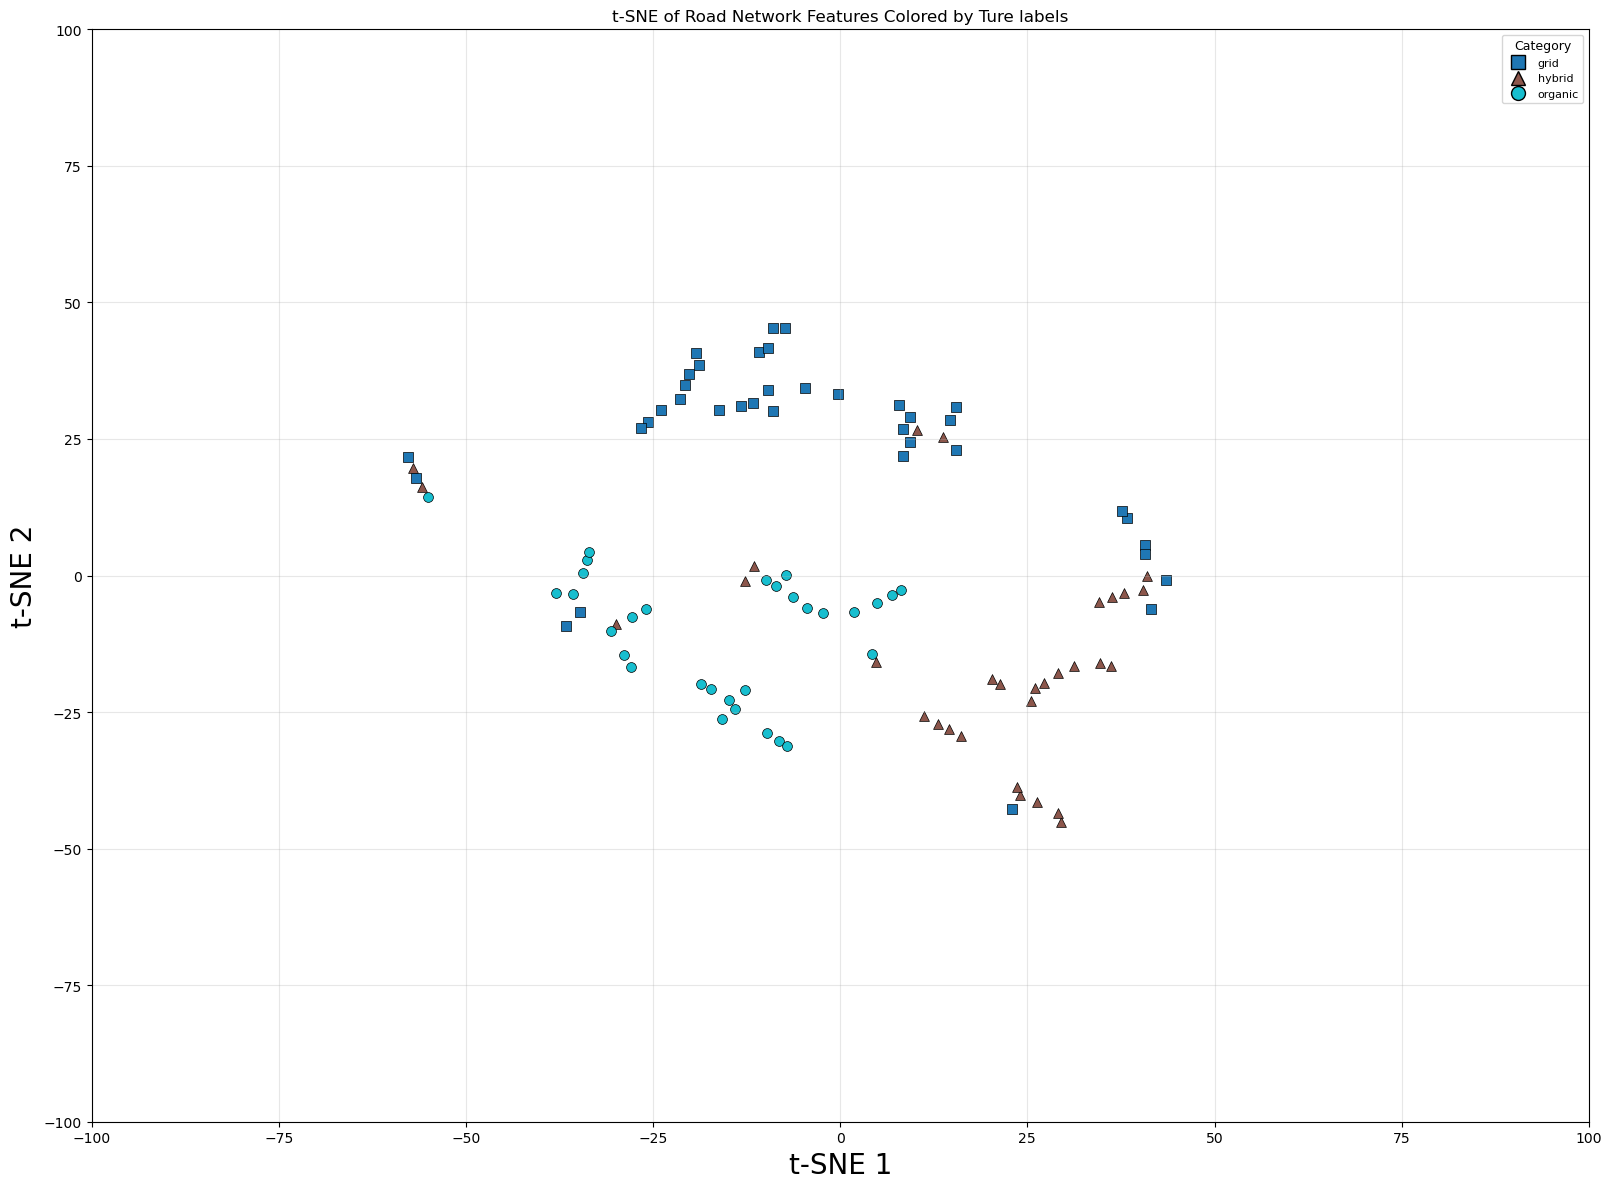

Adjusted Rand Score: 0.5132


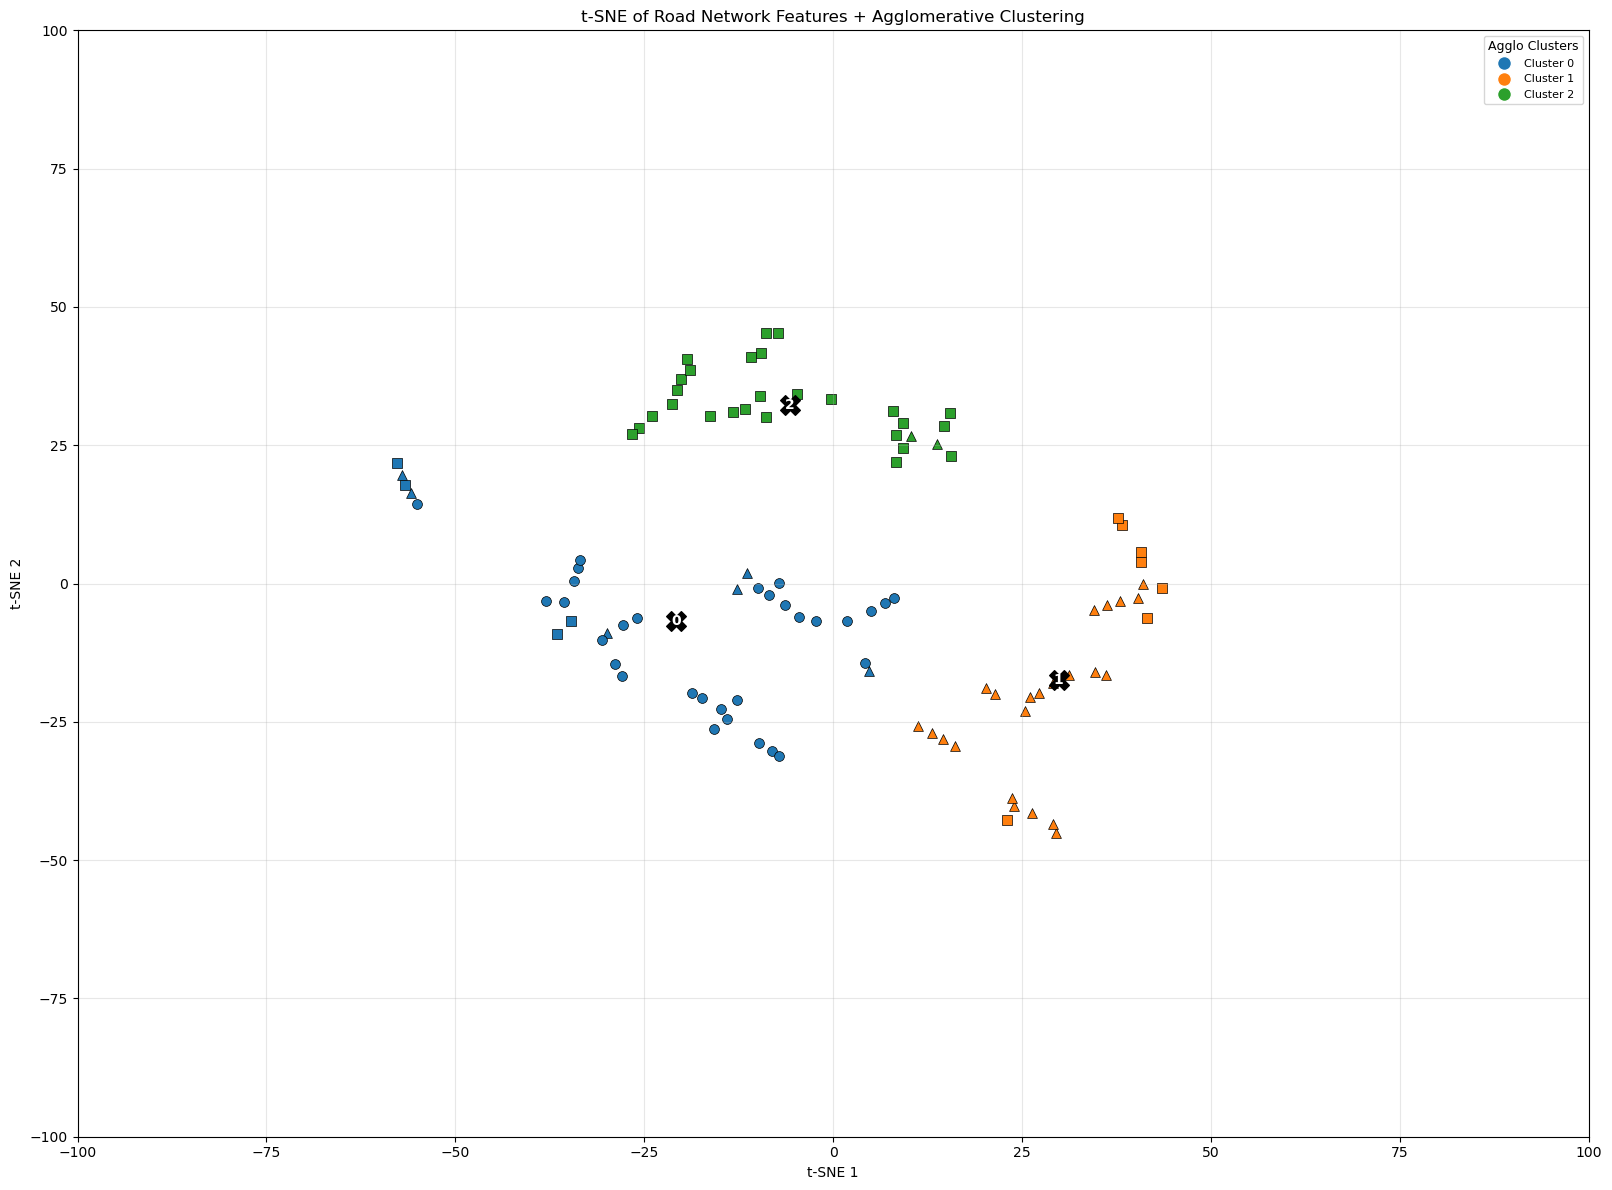

Cluster 0 center: San Juan, Puerto Rico (organic)
Cluster 1 center: La Défense, Paris, France (hybrid)
Cluster 2 center: Midtown Manhattan, New York, USA (grid)


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

csv_path = '15road_network_features.csv'
df = pd.read_csv(csv_path)

df['category'] = df['type'].astype(str)
feature_columns = [
    'number_of_branches', 'avg_branch_length', 'edge_density',
    'mean_betweenness_centrality', 'diameter', 'average_path_length',
    'assortativity', 'spectral_entropy', 'circuity',
    'mass_quartile_1', 'mass_quartile_2', 'mass_quartile_3', 'mass_quartile_4',
    'circular_std_dev', 'weighted_entropy', 'orientation_order',
    'fractal_dimension', 'algebraic_connectivity', 'avg_bending_energy'
]
X = df[feature_columns].values
# Normalize the features using standardization

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# Compute pairwise Euclidean distances between samples
dist_matrix = euclidean_distances(X_norm)

# Save distance matrix
sample_ids = df['region_name'].tolist()
dist_df = pd.DataFrame(dist_matrix, index=sample_ids, columns=sample_ids)
dist_df.to_csv('road_pairwise_euclidean_distances.csv')


tsne = TSNE(
    n_components=2,
    metric="precomputed",
    init='random',
    random_state=42,
    perplexity=3,
    learning_rate=100,
    n_iter=1000
)
tsne_coords = tsne.fit_transform(dist_matrix)
# Create DataFrame for plotting
df_plot = pd.DataFrame({
    "x": tsne_coords[:, 0],
    "y": tsne_coords[:, 1],
    "category": df['category'],
    "graph": sample_ids,
    "true_label": df['type']
})

# Map graph names to their categories
graph_to_category = dict(zip(sample_ids, df['category']))
# Define markers for each category
category_markers = {
    'organic': 'o', # circle
    'grid': 's', # square
    'hybrid': '^' # triangle
}
# Plot t-SNE without clustering (all points in one color, markers by category)
plt.figure(figsize=(16, 12))
unique_categories = np.unique(df['category'])
for _, row in df_plot.iterrows():
    marker = category_markers.get(row['category'], 'o') # default to circle if not found
    plt.scatter(
        row['x'],
        row['y'],
        color='blue',
        marker=marker,
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for categories (markers)
legend_elements = [
    Line2D([0], [0], marker=category_markers.get(category, 'o'), color='w', label=category,
           markerfacecolor='blue', markeredgecolor='k', markersize=10)
    for category in unique_categories
]
plt.legend(handles=legend_elements, title="Category", loc='upper right',
           fontsize=8, title_fontsize=9)
plt.title("t-SNE of Road Network Features (No Clustering)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.show()

# Plot t-SNE colored by true categories with different markers
plt.figure(figsize=(16, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_categories)))
category_color_map = dict(zip(unique_categories, colors))
for _, row in df_plot.iterrows():
    color = category_color_map[row['category']]
    marker = category_markers.get(row['category'], 'o') # default to circle if not found
    plt.scatter(
        row['x'],
        row['y'],
        color=color,
        marker=marker,
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for categories with respective markers
legend_elements = [
    Line2D([0], [0], marker=category_markers.get(category, 'o'), color='w', label=category,
           markerfacecolor=category_color_map[category], markeredgecolor='k', markersize=10)
    for category in unique_categories
]
plt.legend(handles=legend_elements, title="Category", loc='upper right',
           fontsize=8, title_fontsize=9)
plt.title("t-SNE of Road Network Features Colored by Ture labels")
plt.xlabel("t-SNE 1", fontsize =20)
plt.ylabel("t-SNE 2", fontsize =20)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.savefig('road.png', dpi=300)
plt.show()

# Perform Agglomerative Clustering on t-SNE coordinates
n_clusters = 3 # Adjusted to 3 for grid, organic, hybrid
agglo = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward'
)
cluster_labels = agglo.fit_predict(tsne_coords)
# NEW: Compute Adjusted Rand Score here
le = LabelEncoder()
true_labels = le.fit_transform(df['type'])
ars = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Score: {ars:.4f}")
# Update df_plot with clusters
df_plot['cluster'] = cluster_labels
# Compute centroids
centroids = df_plot.groupby('cluster')[['x', 'y']].mean().reset_index()
# Plot t-SNE with clustering (colors by cluster, markers by category)
plt.figure(figsize=(16, 12))
cmap = plt.get_cmap("tab10")
for _, row in df_plot.iterrows():
    color = cmap(row['cluster'] % 10)
    marker = category_markers.get(row['category'], 'o') # default to circle if not found
    plt.scatter(
        row['x'],
        row['y'],
        color=color,
        marker=marker,
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for clusters (using default marker 'o' for simplicity)
cluster_names = [f"Cluster {i}" for i in range(n_clusters)]
legend_elements_clusters = [
    Line2D([0], [0], marker='o', color='w', label=cluster_names[c],
           markerfacecolor=cmap(c % 10), markersize=10)
    for c in range(n_clusters)
]
plt.legend(handles=legend_elements_clusters,
           title="Agglo Clusters",
           loc='upper right',
           fontsize=8,
           title_fontsize=9)
plt.scatter(centroids['x'], centroids['y'],
            c='black', marker='X', s=200,
            label='Centroids')
for _, row in centroids.iterrows():
    plt.text(row['x'], row['y'], f"{int(row['cluster'])}",
             color='white', weight='bold',
             ha='center', va='center')
plt.title("t-SNE of Road Network Features + Agglomerative Clustering")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.show()

# Function to find cluster center (closest graph to centroid)
def find_cluster_center(df, cluster_id):
    cluster_df = df[df['cluster'] == cluster_id]
    if cluster_df.empty:
        return None, None
    centroid = np.array([cluster_df['x'].mean(), cluster_df['y'].mean()])
    cluster_coords = cluster_df[['x', 'y']].to_numpy()
    distances = cdist([centroid], cluster_coords, metric='euclidean')[0]
    closest_idx = np.argmin(distances)
    closest_graph = cluster_df.iloc[closest_idx]['graph']
    return closest_graph, centroid
# Print centers for each cluster (no structure plotting for roads)
for cluster_id in range(n_clusters):
    closest_graph, centroid = find_cluster_center(df_plot, cluster_id)
    if closest_graph is None:
        print(f"Cluster {cluster_id} is empty")
        continue
    category = graph_to_category[closest_graph]
    print(f"Cluster {cluster_id} center: {closest_graph} ({category})")